Saving sha.jpg to sha.jpg


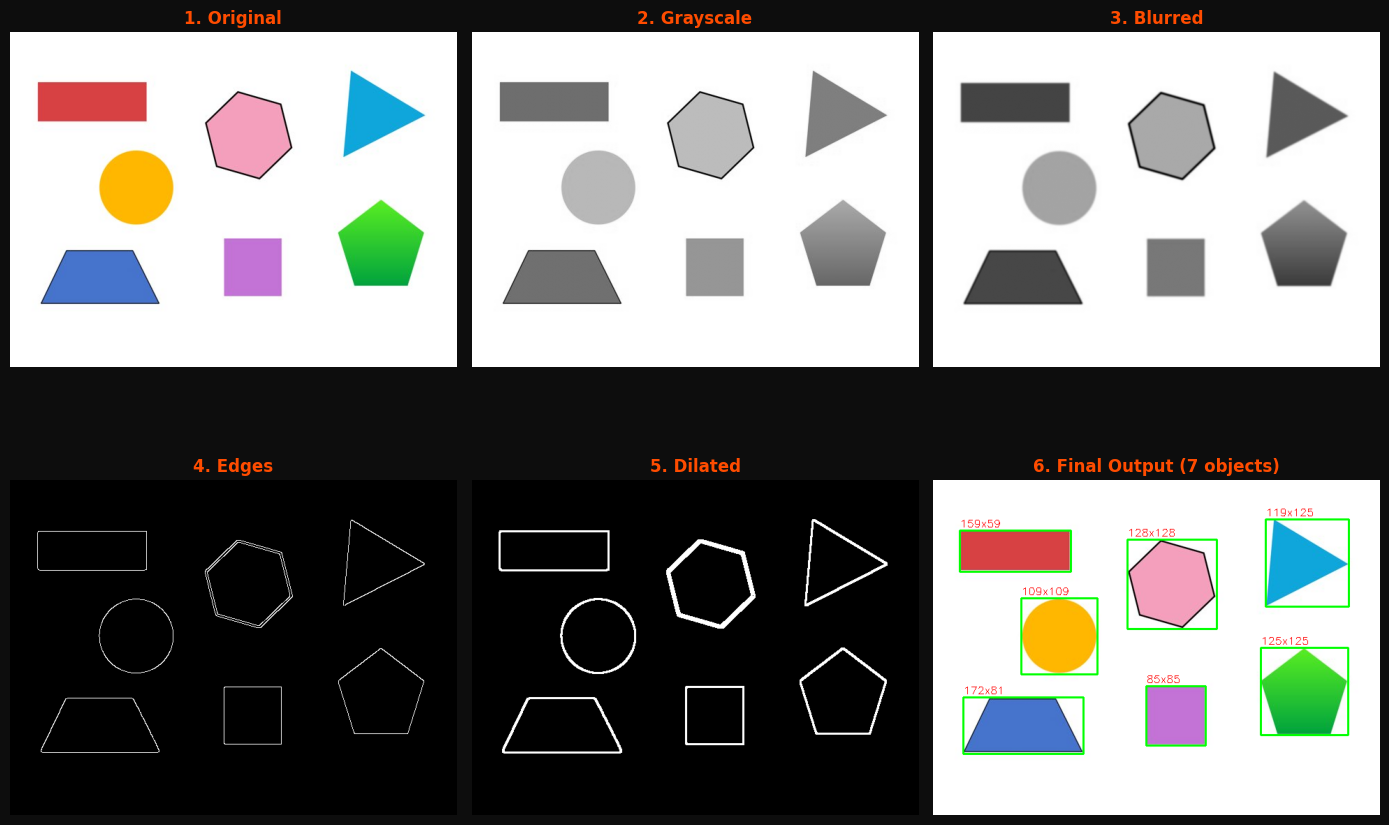

Object Count: 7
Average Area: 9511.57
Inference Time (sec): 0.0015
Total Latency (sec): 0.006


In [4]:
!pip install opencv-python matplotlib

import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

start_total = time.time()

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 1: Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Step 3: Edge Detection
edges = cv2.Canny(blur, 50, 150)

# Step 4: Dilation
kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)

# Step 5: Contours + Measurement
start_inf = time.time()

contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img_rgb.copy()
count = 0
areas = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 500:
        count += 1
        areas.append(area)

        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)
        cv2.putText(output, f"{w}x{h}", (x, y-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

end_inf = time.time()
end_total = time.time()

# Metrics
inference_time = end_inf - start_inf
total_latency = end_total - start_total

# Plot all steps
plt.figure(figsize=(14,10))

plt.subplot(2,3,1)
plt.title("1. Original")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2,3,2)
plt.title("2. Grayscale")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2,3,3)
plt.title("3. Blurred")
plt.imshow(blur, cmap='gray')
plt.axis('off')

plt.subplot(2,3,4)
plt.title("4. Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(2,3,5)
plt.title("5. Dilated")
plt.imshow(dilated, cmap='gray')
plt.axis('off')

plt.subplot(2,3,6)
plt.title(f"6. Final Output ({count} objects)")
plt.imshow(output)
plt.axis('off')

plt.tight_layout()
plt.show()

print("Object Count:", count)
print("Average Area:", round(np.mean(areas),2) if areas else 0)
print("Inference Time (sec):", round(inference_time, 4))
print("Total Latency (sec):", round(total_latency, 4))